# Análise de Fraudes — Dataset Real (ULB / Worldline)

EDA do `data/raw/creditcard.csv`: 284.807 transações europeias (set/2013), 492 fraudes (0,17%).
Colunas: `Time` (segundos desde a 1ª tx), `V1..V28` (PCA anonimizado), `Amount`, `Class`.
Baixar com: `kaggle datasets download mlg-ulb/creditcardfraud -p data/raw --unzip`

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta, timezone
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

from pathlib import Path
def _achar_csv():
    cands = [Path('data/raw/creditcard.csv'),
             Path('../data/raw/creditcard.csv'),
             Path.cwd() / 'data/raw/creditcard.csv',
             Path.cwd().parent / 'data/raw/creditcard.csv']
    for c in cands:
        if c.exists():
            return str(c)
    raise FileNotFoundError('creditcard.csv não achado. Baixe com: kaggle datasets download mlg-ulb/creditcardfraud -p data/raw --unzip (rodando da raiz do repo)')
CSV = _achar_csv()
print('CSV:', CSV)
BASE = datetime(2013, 9, 1, tzinfo=timezone.utc)
print('Bibliotecas OK')

CSV: ../data/raw/creditcard.csv
Bibliotecas OK


## 1. Carga e perfil geral

In [5]:
df = pd.read_csv(CSV)
df['timestamp'] = BASE + pd.to_timedelta(df['Time'], unit='s')
df['hour'] = df['timestamp'].dt.hour
df['day'] = df['timestamp'].dt.date

print(f'Total: {len(df)} | Fraudes: {int(df.Class.sum())} ({df.Class.mean()*100:.3f}%)')
print(f'Período: {df.timestamp.min()} -> {df.timestamp.max()}')
df[['Time', 'Amount', 'Class']].describe().round(2)

Total: 284807 | Fraudes: 492 (0.173%)
Período: 2013-09-01 00:00:00+00:00 -> 2013-09-02 23:59:52+00:00


,Time,Amount,Class
count,284807.00,284807.00,284807.00
mean,94813.86,88.35,0.00
std,47488.15,250.12,0.04
min,0.00,0.00,0.00
25%,54201.50,5.60,0.00
50%,84692.00,22.00,0.00
75%,139320.50,77.16,0.00
max,172792.00,25691.16,1.00


Amount médio normal : R$ 88.29
Amount médio fraude : R$ 122.21
Amount mediana normal: 22.0
Amount mediana fraude: 9.25


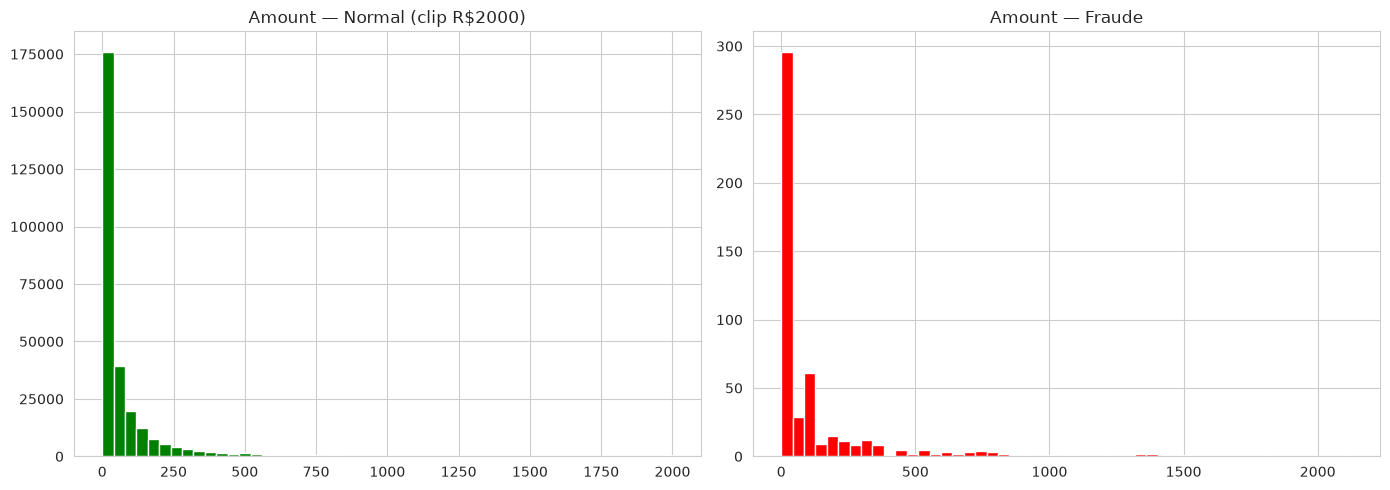

In [6]:
# Amount: normal vs fraude
print('Amount médio normal : R$', round(df.loc[df.Class==0, 'Amount'].mean(), 2))
print('Amount médio fraude : R$', round(df.loc[df.Class==1, 'Amount'].mean(), 2))
print('Amount mediana normal:', round(df.loc[df.Class==0, 'Amount'].median(), 2))
print('Amount mediana fraude:', round(df.loc[df.Class==1, 'Amount'].median(), 2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df.loc[df.Class==0, 'Amount'].clip(upper=2000).hist(bins=50, ax=axes[0], color='green')
axes[0].set_title('Amount — Normal (clip R$2000)')
df.loc[df.Class==1, 'Amount'].hist(bins=50, ax=axes[1], color='red')
axes[1].set_title('Amount — Fraude')
plt.tight_layout()
plt.show()

## 2. Fraude por hora e por dia

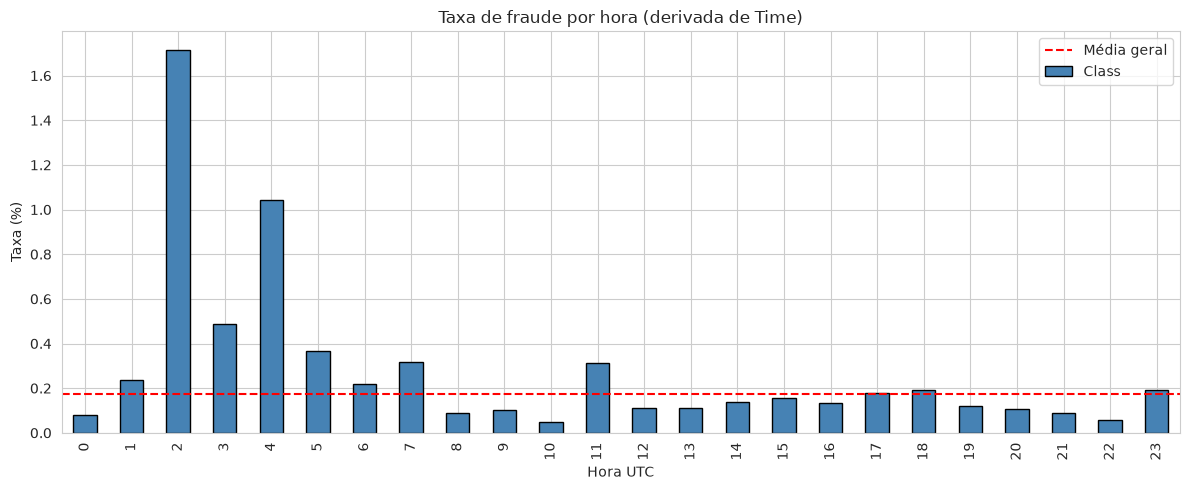

hour
2    1.713
4    1.041
3    0.487
5    0.368
7    0.318
Name: Class, dtype: float64


In [7]:
taxa_hora = df.groupby('hour')['Class'].mean() * 100
plt.figure(figsize=(12, 5))
taxa_hora.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Taxa de fraude por hora (derivada de Time)')
plt.xlabel('Hora UTC')
plt.ylabel('Taxa (%)')
plt.axhline(y=df.Class.mean()*100, color='red', linestyle='--', label='Média geral')
plt.legend()
plt.tight_layout()
plt.show()
print(taxa_hora.sort_values(ascending=False).head().round(3))

## 3. Features V1..V28 — separação entre classes

     normal  fraude  diff_abs
V3    0.012  -7.033     7.045
V14   0.012  -6.972     6.984
V17   0.012  -6.666     6.677
V12   0.011  -6.259     6.270
V10   0.010  -5.677     5.687
V7    0.010  -5.569     5.578
V1    0.008  -4.772     4.780
V4   -0.008   4.542     4.550
V16   0.007  -4.140     4.147
V11  -0.007   3.800     3.807


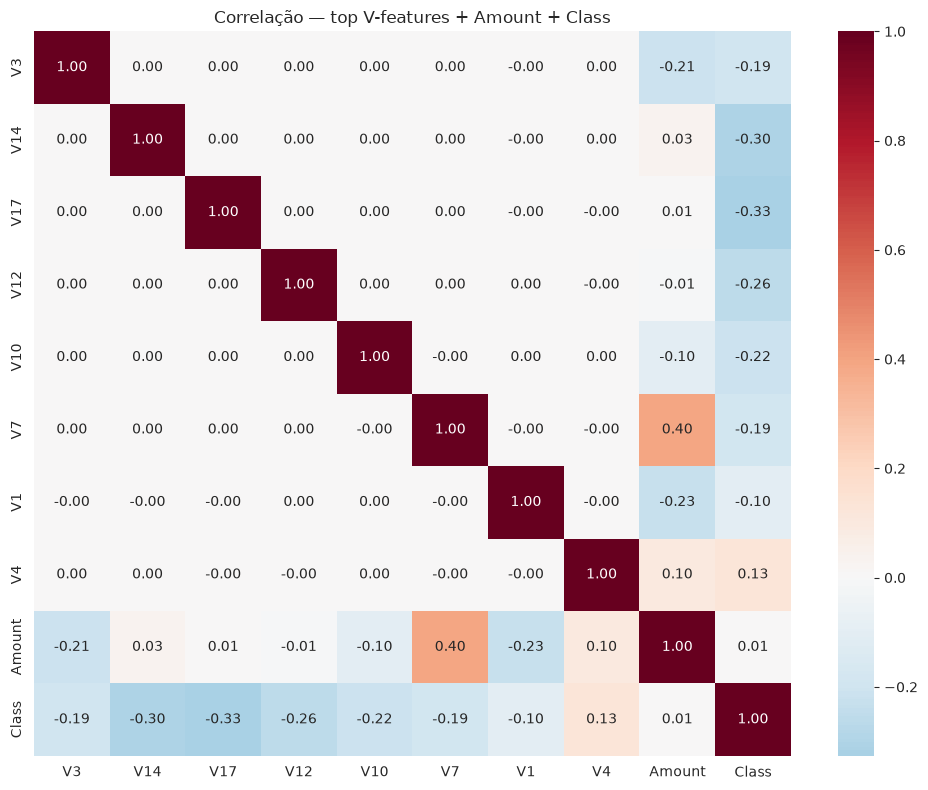

In [8]:
vcols = [f'V{i}' for i in range(1, 29)]
medias = df.groupby('Class')[vcols].mean().T
medias.columns = ['normal', 'fraude']
medias['diff_abs'] = (medias['fraude'] - medias['normal']).abs()
print(medias.sort_values('diff_abs', ascending=False).head(10).round(3))

top = medias.sort_values('diff_abs', ascending=False).head(8).index.tolist()
corr = df[top + ['Amount', 'Class']].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title('Correlação — top V-features + Amount + Class')
plt.tight_layout()
plt.show()

## 4. Regras do pipeline avaliadas no dado real

In [9]:
from sklearn.metrics import precision_score, recall_score, f1_score

df['regra_valor'] = df['Amount'] > 10000
df['regra_horario'] = df['hour'].between(0, 5)
df['regras_ativadas'] = df[['regra_valor', 'regra_horario']].sum(axis=1)
df['alerta_regra'] = df['regras_ativadas'] >= 1

print('Regra valor ativada  :', int(df.regra_valor.sum()))
print('Regra horário ativada:', int(df.regra_horario.sum()))
print('Alertas (>=1 regra)  :', int(df.alerta_regra.sum()))

y_true, y_pred = df['Class'], df['alerta_regra']
print(f"Precisão: {precision_score(y_true, y_pred):.2%}")
print(f"Recall   : {recall_score(y_true, y_pred):.2%}")
print(f"F1       : {f1_score(y_true, y_pred):.2%}")
print('\nConclusão: regras sozinhas têm recall baixo — justificam o ML v2 (F1 ~85% no holdout).')

Regra valor ativada  : 7
Regra horário ativada: 23934
Alertas (>=1 regra)  : 23940
Precisão: 0.52%
Recall   : 25.20%
F1       : 1.02%

Conclusão: regras sozinhas têm recall baixo — justificam o ML v2 (F1 ~85% no holdout).
